<a href="https://colab.research.google.com/github/jahnavimala/data-cleaning-visualization-project/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# =====================================
# STUDENT PERFORMANCE ANALYSIS PROJECT
# =====================================

# Step 1: Import Libraries
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
# Step 2: Download Dataset from Kaggle
path = kagglehub.dataset_download(
    "spscientist/students-performance-in-exams"
)

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.
Path to dataset files: /kaggle/input/students-performance-in-exams


In [12]:
# Step 3: Find CSV File
files = os.listdir(path)
print("\nFiles in dataset folder:")
print(files)

csv_file = None

for file in files:
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)
        break



Files in dataset folder:
['StudentsPerformance.csv']


In [13]:
# Step 4: Load Dataset
df = pd.read_csv(csv_file)

print("\n========== FIRST 5 ROWS ==========")
print(df.head())


========== FIRST 5 ROWS ==========
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [14]:
# Step 5: Basic Exploration
print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns)

print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())


========== DATASET SHAPE ==========
(1000, 8)

========== COLUMN NAMES ==========
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), o

In [15]:
# Step 6: Data Cleaning

# Missing values
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# Fill missing values if present
df.fillna(df.mean(numeric_only=True), inplace=True)

# Duplicate rows
print("\n========== DUPLICATES ==========")
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("\nUpdated Columns:")
print(df.columns)


========== MISSING VALUES ==========
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

========== DUPLICATES ==========
0

Updated Columns:
Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [16]:
# Step 7: Data Analysis

# Average scores
print("\n========== AVERAGE SCORES ==========")
print(df[['math_score', 'reading_score', 'writing_score']].mean())

# Gender-wise analysis
gender_scores = df.groupby('gender')[
    ['math_score', 'reading_score', 'writing_score']
].mean()

print("\n========== GENDER ANALYSIS ==========")
print(gender_scores)


========== AVERAGE SCORES ==========
math_score       66.089
reading_score    69.169
writing_score    68.054
dtype: float64

========== GENDER ANALYSIS ==========
        math_score  reading_score  writing_score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


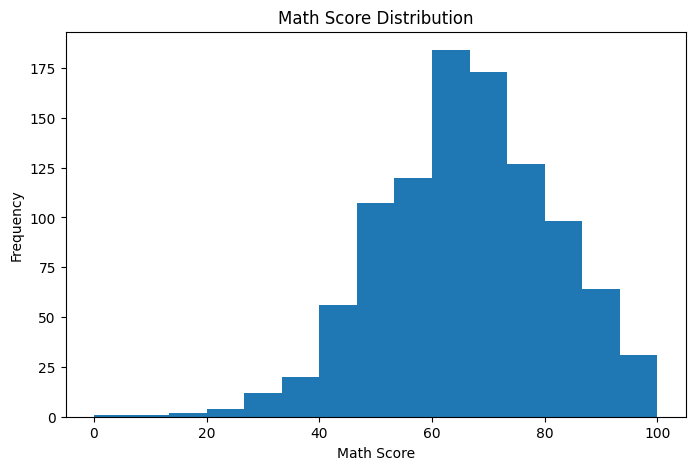

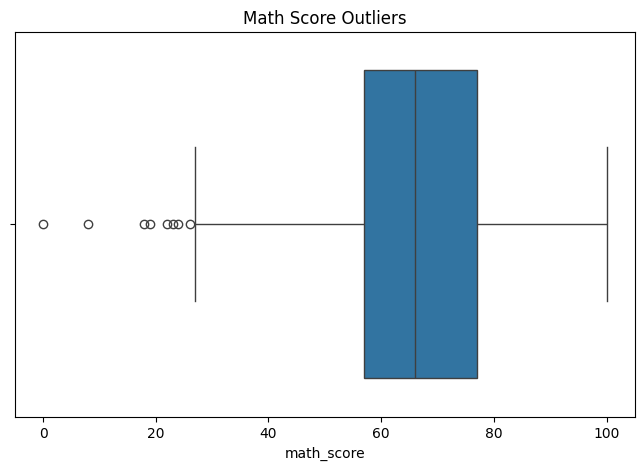

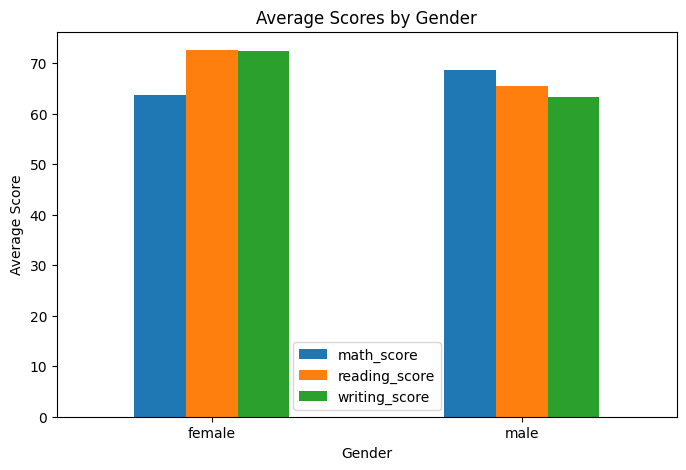

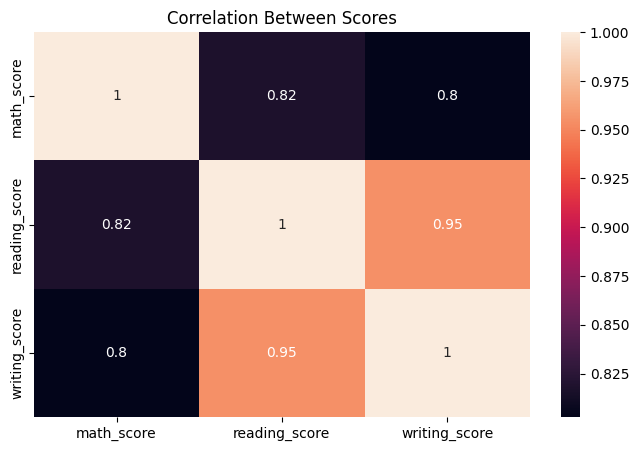

In [17]:
# Step 8: Visualizations

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['math_score'], bins=15)
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.show()


# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['math_score'])
plt.title("Math Score Outliers")
plt.show()


# Bar chart
gender_scores.plot(kind='bar', figsize=(8, 5))
plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.show()


# Heatmap
correlation = df[
    ['math_score', 'reading_score', 'writing_score']
].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Between Scores")
plt.show()

In [18]:
# Step 9: Top Performers
top_students = df[
    (df['math_score'] > 90) &
    (df['reading_score'] > 90) &
    (df['writing_score'] > 90)
]

print("\n========== TOP PERFORMERS ==========")
print(top_students)


========== TOP PERFORMERS ==========
     gender race/ethnicity parental_level_of_education         lunch  \
114  female        group E           bachelor's degree      standard   
149    male        group E          associate's degree  free/reduced   
165  female        group C           bachelor's degree      standard   
179  female        group D            some high school      standard   
451  female        group E                some college      standard   
458  female        group E           bachelor's degree      standard   
546  female        group A            some high school      standard   
566  female        group E           bachelor's degree  free/reduced   
571    male        group A           bachelor's degree      standard   
594  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
685  female        group E             master's degree      standard   
712  female        group D

In [19]:
# Step 10: Final Insights
print("\n========== PROJECT INSIGHTS ==========")
print("1. Compare student performance across genders.")
print("2. Detect outliers in scores.")
print("3. Understand subject correlations.")
print("4. Identify top-performing students.")


========== PROJECT INSIGHTS ==========
1. Compare student performance across genders.
2. Detect outliers in scores.
3. Understand subject correlations.
4. Identify top-performing students.
